# Import libraries, load and transform data

In [1]:

!pip install -U -q evaluate transformers datasets>=2.14.5 accelerate>=0.27 mlflow 2>/dev/null

The system cannot find the path specified.


In [2]:
# Importing necessary libraries and modules
import warnings  # Import the 'warnings' module for handling warnings
warnings.filterwarnings("ignore")  # Ignore warnings during execution

import gc  # Import the 'gc' module for garbage collection
import numpy as np  # Import NumPy for numerical operations
import pandas as pd  # Import Pandas for data manipulation
import itertools  # Import 'itertools' for iterators and looping
from collections import Counter  # Import 'Counter' for counting elements
import matplotlib.pyplot as plt  # Import Matplotlib for data visualization
from sklearn.metrics import (  # Import various metrics from scikit-learn
    accuracy_score,  # For calculating accuracy
    roc_auc_score,  # For ROC AUC score
    confusion_matrix,  # For confusion matrix
    classification_report,  # For classification report
    f1_score  # For F1 score
)

# Import custom modules and classes
from imblearn.over_sampling import RandomOverSampler # import RandomOverSampler
import accelerate # Import the 'accelerate' module
import evaluate  # Import the 'evaluate' module
from datasets import Dataset, Image, ClassLabel  # Import custom 'Dataset', 'ClassLabel', and 'Image' classes
from transformers import (  # Import various modules from the Transformers library
    TrainingArguments,  # For training arguments
    Trainer,  # For model training
    ViTImageProcessor,  # For processing image data with ViT models
    ViTForImageClassification,  # ViT model for image classification
    DefaultDataCollator  # For collating data in the default way
)
import torch  # Import PyTorch for deep learning
from torch.utils.data import DataLoader  # For creating data loaders
from torchvision.transforms import (  # Import image transformation functions
    CenterCrop,  # Center crop an image
    Compose,  # Compose multiple image transformations
    Normalize,  # Normalize image pixel values
    RandomRotation,  # Apply random rotation to images
    RandomResizedCrop,  # Crop and resize images randomly
    RandomHorizontalFlip,  # Apply random horizontal flip
    RandomAdjustSharpness,  # Adjust sharpness randomly
    Resize,  # Resize images
    ToTensor  # Convert images to PyTorch tensors
)

In [3]:
# Import the necessary module from the Python Imaging Library (PIL).
from PIL import ImageFile

# Enable the option to load truncated images.
# This setting allows the PIL library to attempt loading images even if they are corrupted or incomplete.
ImageFile.LOAD_TRUNCATED_IMAGES = True

In [4]:
from pathlib import Path
import shutil
import random

# Original dataset
source = Path(r"C:\Users\DELL\Desktop\FakeImage\dataset")

# New 1000-image dataset
destination = Path(r"C:\Users\DELL\Desktop\FakeImage\dataset_1000")

random.seed(42)

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

# Collect images separately by split and class
images = {
    "train": {
        "FAKE": [],
        "REAL": []
    },
    "test": {
        "FAKE": [],
        "REAL": []
    }
}

# Find images
for file in source.rglob("*"):

    if not file.is_file() or file.suffix.lower() not in IMAGE_EXTENSIONS:
        continue

    parts_upper = [p.upper() for p in file.parts]

    split = None
    label = None

    if "TRAIN" in parts_upper:
        split = "train"
    elif "TEST" in parts_upper:
        split = "test"

    if "FAKE" in parts_upper:
        label = "FAKE"
    elif "REAL" in parts_upper:
        label = "REAL"

    if split and label:
        images[split][label].append(file)


# Display available images
print("Available images:")
for split in images:
    for label in images[split]:
        print(f"{split.upper()} {label}: {len(images[split][label])}")


# ==========================================
# TARGET: 1000 IMAGES
# ==========================================

targets = {
    "train": {
        "FAKE": 400,
        "REAL": 400
    },
    "test": {
        "FAKE": 100,
        "REAL": 100
    }
}


# ==========================================
# SELECT AND COPY
# ==========================================

for split in targets:

    for label in targets[split]:

        available = images[split][label]
        required = targets[split][label]

        if len(available) < required:
            raise ValueError(
                f"Not enough {split}/{label} images. "
                f"Available: {len(available)}, "
                f"Required: {required}"
            )

        selected = random.sample(available, required)

        for file in selected:

            relative_path = file.relative_to(source)

            destination_file = destination / relative_path

            destination_file.parent.mkdir(
                parents=True,
                exist_ok=True
            )

            shutil.copy2(file, destination_file)


print("\n================================")
print("REDUCED DATASET CREATED")
print("================================")

print("Training images: 800")
print("Testing images: 200")
print("Total images: 1000")
print("FAKE: 500")
print("REAL: 500")

print("\nLocation:")
print(destination)

Available images:
TRAIN FAKE: 50000
TRAIN REAL: 50000
TEST FAKE: 10000
TEST REAL: 10000

REDUCED DATASET CREATED
Training images: 800
Testing images: 200
Total images: 1000
FAKE: 500
REAL: 500

Location:
C:\Users\DELL\Desktop\FakeImage\dataset_1000


In [5]:
from pathlib import Path
import pandas as pd

dataset_path = Path(r"C:\Users\DELL\Desktop\FakeImage\dataset_1000")

image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

file_names = []
labels = []

for file in sorted(dataset_path.rglob("*")):

    if file.is_file() and file.suffix.lower() in image_extensions:

        parts_upper = [p.upper() for p in file.parts]

        if "FAKE" in parts_upper:
            label = "FAKE"
        elif "REAL" in parts_upper:
            label = "REAL"
        else:
            continue

        file_names.append(str(file))
        labels.append(label)

df = pd.DataFrame({
    "image": file_names,
    "label": labels
})

print("Total images:", len(df))
print("Shape:", df.shape)
print("\nLabels:")
print(df["label"].value_counts())
print("\nUnique labels:")
print(df["label"].unique())

Total images: 1000
Shape: (1000, 2)

Labels:
label
FAKE    500
REAL    500
Name: count, dtype: int64

Unique labels:
['FAKE' 'REAL']


In [6]:
from datasets import Dataset, Image

# Make sure image column contains strings/paths
df["image"] = df["image"].astype(str)

dataset = Dataset.from_pandas(df)
dataset = dataset.cast_column("image", Image())

In [7]:
# Create a dataset from a Pandas DataFrame.
dataset = Dataset.from_pandas(df).cast_column("image", Image())

In [8]:
print(dataset)
print("Number of rows:", len(dataset))
print("Columns:", dataset.column_names)

Dataset({
    features: ['image', 'label'],
    num_rows: 1000
})
Number of rows: 1000
Columns: ['image', 'label']


In [9]:
print(dataset)
print("Number of rows:", len(dataset))
print("Columns:", dataset.column_names)

Dataset({
    features: ['image', 'label'],
    num_rows: 1000
})
Number of rows: 1000
Columns: ['image', 'label']


In [10]:

labels_subset = labels[:5]

# Printing the subset of labels to inspect the content.
print(labels_subset)

['FAKE', 'FAKE', 'FAKE', 'FAKE', 'FAKE']


In [11]:
# Create a list of unique labels by converting 'labels' to a set and then back to a list
labels_list = ['REAL', 'FAKE'] #list(set(labels))

# Initialize empty dictionaries to map labels to IDs and vice versa
label2id, id2label = dict(), dict()

# Iterate over the unique labels and assign each label an ID, and vice versa
for i, label in enumerate(labels_list):
    label2id[label] = i  # Map the label to its corresponding ID
    id2label[i] = label  # Map the ID to its corresponding label

# Print the resulting dictionaries for reference
print("Mapping of IDs to Labels:", id2label, '\n')
print("Mapping of Labels to IDs:", label2id)

Mapping of IDs to Labels: {0: 'REAL', 1: 'FAKE'} 

Mapping of Labels to IDs: {'REAL': 0, 'FAKE': 1}


In [12]:
# Creating classlabels to match labels to IDs
ClassLabels = ClassLabel(num_classes=len(labels_list), names=labels_list)

# Mapping labels to IDs
def map_label2id(example):
    example['label'] = ClassLabels.str2int(example['label'])
    return example

dataset = dataset.map(map_label2id, batched=True)

# Casting label column to ClassLabel Object
dataset = dataset.cast_column('label', ClassLabels)

# Splitting the dataset into training and testing sets using an 60-40 split ratio.
dataset = dataset.train_test_split(test_size=0.4, shuffle=True, stratify_by_column="label")

# Extracting the training data from the split dataset.
train_data = dataset['train']

# Extracting the testing data from the split dataset.
test_data = dataset['test']

Casting the dataset: 100%|██████████| 1000/1000 [00:00<?, ? examples/s]


In [13]:
# Define the pre-trained ViT model string
model_str = "dima806/ai_vs_real_image_detection" #'google/vit-base-patch16-224-in21k'

# Create a processor for ViT model input from the pre-trained model
processor = ViTImageProcessor.from_pretrained(model_str)

# Retrieve the image mean and standard deviation used for normalization
image_mean, image_std = processor.image_mean, processor.image_std

# Get the size (height) of the ViT model's input images
size = processor.size["height"]
print("Size: ", size)

# Define a normalization transformation for the input images
normalize = Normalize(mean=image_mean, std=image_std)

# Define a set of transformations for training data
_train_transforms = Compose(
    [
        Resize((size, size)),             # Resize images to the ViT model's input size
        RandomRotation(90),               # Apply random rotation
        RandomAdjustSharpness(2),         # Adjust sharpness randomly
        ToTensor(),                       # Convert images to tensors
        normalize                         # Normalize images using mean and std
    ]
)

# Define a set of transformations for validation data
_val_transforms = Compose(
    [
        Resize((size, size)),             # Resize images to the ViT model's input size
        ToTensor(),                       # Convert images to tensors
        normalize                         # Normalize images using mean and std
    ]
)

# Define a function to apply training transformations to a batch of examples
def train_transforms(examples):
    examples['pixel_values'] = [_train_transforms(image.convert("RGB")) for image in examples['image']]
    return examples

# Define a function to apply validation transformations to a batch of examples
def val_transforms(examples):
    examples['pixel_values'] = [_val_transforms(image.convert("RGB")) for image in examples['image']]
    return examples

Size:  224


In [14]:
# Set the transforms for the training data
train_data.set_transform(train_transforms)

# Set the transforms for the test/validation data
test_data.set_transform(val_transforms)

In [15]:
# Define a collate function that prepares batched data for model training.
def collate_fn(examples):
    # Stack the pixel values from individual examples into a single tensor.
    pixel_values = torch.stack([example["pixel_values"] for example in examples])
    
    # Convert the label strings in examples to corresponding numeric IDs using label2id dictionary.
    labels = torch.tensor([example['label'] for example in examples])
    
    # Return a dictionary containing the batched pixel values and labels.
    return {"pixel_values": pixel_values, "labels": labels}

# Load, train, and evaluate model

In [16]:
# Create a ViTForImageClassification model from a pretrained checkpoint with a specified number of output labels.
model = ViTForImageClassification.from_pretrained(model_str, num_labels=len(labels_list))

# Configure the mapping of class labels to their corresponding indices for later reference.
model.config.id2label = id2label
model.config.label2id = label2id

# Calculate and print the number of trainable parameters in millions for the model.
print(model.num_parameters(only_trainable=True) / 1e6)

Loading weights: 100%|██████████| 200/200 [00:00<00:00, 1948.40it/s]

85.800194


In [17]:
# Load the accuracy metric from a module named 'evaluate'
accuracy = evaluate.load("accuracy")

# Define a function 'compute_metrics' to calculate evaluation metrics
def compute_metrics(eval_pred):
    # Extract model predictions from the evaluation prediction object
    predictions = eval_pred.predictions
    
    # Extract true labels from the evaluation prediction object
    label_ids = eval_pred.label_ids
    
    # Calculate accuracy using the loaded accuracy metric
    # Convert model predictions to class labels by selecting the class with the highest probability (argmax)
    predicted_labels = predictions.argmax(axis=1)
    
    # Calculate accuracy score by comparing predicted labels to true labels
    acc_score = accuracy.compute(predictions=predicted_labels, references=label_ids)['accuracy']
    
    # Return the computed accuracy as a dictionary with the key "accuracy"
    return {
        "accuracy": acc_score
    }

In [18]:
from transformers import TrainingArguments

# Evaluation metric
metric_name = "accuracy"

# Model/output directory
model_name = "ai_vs_real_image_detection"

# Train for 10 epochs
num_train_epochs = 10

# Configure training settings
args = TrainingArguments(
    # Directory for model checkpoints
    output_dir=model_name,

    # Directory for logs
    logging_dir="./logs",

    # Evaluate after every epoch
    eval_strategy="epoch",

    # Learning rate
    learning_rate=1e-5,

    # Training batch size
    per_device_train_batch_size=64,

    # Evaluation batch size
    per_device_eval_batch_size=32,

    # Number of epochs
    num_train_epochs=num_train_epochs,

    # Weight decay
    weight_decay=0.02,

    # Warm-up steps
    warmup_steps=10,

    # Keep image and label columns
    remove_unused_columns=False,

    # Save after every epoch
    save_strategy="epoch",

    # Load the best model at the end
    load_best_model_at_end=True,

    # Select best model based on accuracy
    metric_for_best_model="accuracy",
    greater_is_better=True,

    # Keep only the best/last limited checkpoint
    save_total_limit=1,

    # Log training loss every 5 steps
    logging_strategy="steps",
    logging_steps=5,

    # Disable external logging
    report_to="none"
)

print("TrainingArguments created successfully!")

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


TrainingArguments created successfully!


In [19]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_data,
    eval_dataset=test_data,
    data_collator=collate_fn,
    compute_metrics=compute_metrics,
    processing_class=processor,
)

print("Trainer created successfully!")
print("Training samples:", len(trainer.train_dataset))
print("Testing samples:", len(trainer.eval_dataset))
print("Epochs:", args.num_train_epochs)

Trainer created successfully!
Training samples: 600
Testing samples: 400
Epochs: 10


In [20]:
# Evaluate the pre-training model's performance on a test dataset.
# This function calculates various metrics such as accuracy, loss, etc.,
# to assess how well the model is performing on unseen data.

trainer.evaluate()

Training Loss,Validation Loss,Epoch,Accuracy
No log,0.056749,0,0.980000


{'eval_loss': 0.056748952716588974, 'eval_accuracy': 0.98}

In [21]:
print("train_data:", len(train_data))
print("test_data:", len(test_data))

print("\nTrain dataset:")
print(train_data)

print("\nTest dataset:")
print(test_data)

train_data: 600
test_data: 400

Train dataset:
Dataset({
    features: ['image', 'label'],
    num_rows: 600
})

Test dataset:
Dataset({
    features: ['image', 'label'],
    num_rows: 400
})


In [22]:
print("df rows:", len(df))
print("df shape:", df.shape)

print("\nDataFrame:")
print(df.head())

print("\nColumns:")
print(df.columns.tolist())

df rows: 1000
df shape: (1000, 2)

DataFrame:
                                               image label
0  C:\Users\DELL\Desktop\FakeImage\dataset_1000\t...  FAKE
1  C:\Users\DELL\Desktop\FakeImage\dataset_1000\t...  FAKE
2  C:\Users\DELL\Desktop\FakeImage\dataset_1000\t...  FAKE
3  C:\Users\DELL\Desktop\FakeImage\dataset_1000\t...  FAKE
4  C:\Users\DELL\Desktop\FakeImage\dataset_1000\t...  FAKE

Columns:
['image', 'label']


In [23]:
df.head()

,image,label
0,C:\Users\DELL\Desktop\FakeImage\dataset_1000\t...,FAKE
1,C:\Users\DELL\Desktop\FakeImage\dataset_1000\t...,FAKE
2,C:\Users\DELL\Desktop\FakeImage\dataset_1000\t...,FAKE
3,C:\Users\DELL\Desktop\FakeImage\dataset_1000\t...,FAKE
4,C:\Users\DELL\Desktop\FakeImage\dataset_1000\t...,FAKE


In [24]:
# Evaluate the post-training model's performance on the validation or test dataset.
# This function computes various evaluation metrics like accuracy, loss, etc.
# and provides insights into how well the model is performing.

trainer.evaluate()

Training Loss,Validation Loss,Epoch,Accuracy
No log,0.056749,0,0.980000


{'eval_loss': 0.056748952716588974, 'eval_accuracy': 0.98}

In [32]:
print("Training loss points:", len(train_losses))
print("Validation loss points:", len(eval_losses))
print("Accuracy points:", len(accuracies))

print("Evaluation epochs:", eval_epochs)

Training loss points: 0
Validation loss points: 2
Accuracy points: 2
Evaluation epochs: [0, 0]


Writing model shards: 100%|██████████| 1/1 [00:04<00:00,  4.60s/it]


Model and processor saved successfully!


In [26]:
# Save the trained model: This line of code is responsible for saving the model
# that has been trained using the trainer object. It will serialize the model
# and its associated weights, making it possible to reload and use the model
# in the future without the need to retrain it.
trainer.save_model()

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.10it/s]


In [27]:
# Import the 'pipeline' function from the 'transformers' library.
from transformers import pipeline

# Create a pipeline for image classification tasks. 
# You need to specify the 'model_name' and the 'device' to use for inference.
# - 'model_name': The name of the pre-trained model to be used for image classification.
# - 'device': Specifies the device to use for running the model (0 for GPU, -1 for CPU).
pipe = pipeline('image-classification', model=model_name, device=0)

Loading weights: 100%|██████████| 200/200 [00:00<00:00, 3876.26it/s]


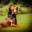

In [28]:
# Accessing an image from the 'test_data' dataset using index 1.
image = test_data[1]["image"]

# Displaying the 'image' variable.
image

In [29]:
# Apply the 'pipe' function to process the 'image' variable.
pipe(image)

[{'label': 'FAKE', 'score': 0.9985401630401611},
 {'label': 'REAL', 'score': 0.0014598392881453037}]

In [30]:
# This line of code accesses the "label" attribute of a specific element in the test_data list.
# It's used to retrieve the actual label associated with a test data point.
id2label[test_data[1]["label"]]

'FAKE'

In [31]:
!zip -r model_checkpoint.zip /kaggle/working/ai_vs_real_image_detection


'zip' is not recognized as an internal or external command,
operable program or batch file.


In [34]:
import os

save_path = r"C:\Users\DELL\Desktop\FakeImage\model\ai_vs_real_image_detection"

os.makedirs(save_path, exist_ok=True)

# Save the trained model
trainer.save_model(save_path)

# Save the processor
processor.save_pretrained(save_path)

print("Model and processor saved successfully!")

Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.83s/it]

Model and processor saved successfully!


In [35]:
from pathlib import Path

model_path = Path(save_path) / "model.safetensors"

print("Model file:", model_path)
print("Model size:", model_path.stat().st_size, "bytes")

Model file: C:\Users\DELL\Desktop\FakeImage\model\ai_vs_real_image_detection\model.safetensors
Model size: 343223968 bytes


In [36]:
from transformers import ViTForImageClassification, ViTImageProcessor

model_dir = r"C:\Users\DELL\Desktop\FakeImage\model\ai_vs_real_image_detection"

test_model = ViTForImageClassification.from_pretrained(
    model_dir,
    local_files_only=True
)

test_processor = ViTImageProcessor.from_pretrained(
    model_dir,
    local_files_only=True
)

print("MODEL LOADED SUCCESSFULLY!")
print("Labels:", test_model.config.id2label)

Loading weights: 100%|██████████| 200/200 [00:00<00:00, 1334.40it/s]

MODEL LOADED SUCCESSFULLY!
Labels: {0: 'REAL', 1: 'FAKE'}


Confusion Matrix:
[[197   3]
 [  5 195]]


<Figure size 700x600 with 0 Axes>

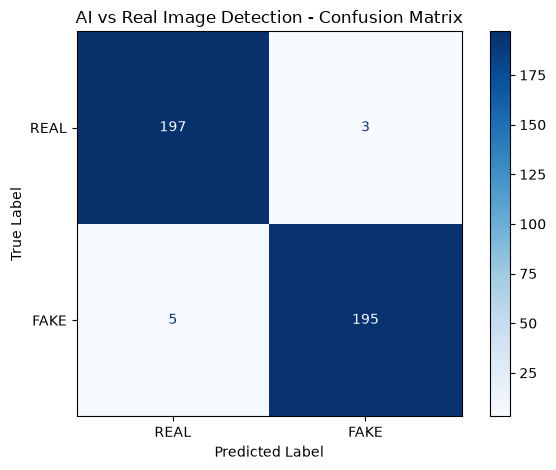


Classification Report:
              precision    recall  f1-score   support

        REAL       0.98      0.98      0.98       200
        FAKE       0.98      0.97      0.98       200

    accuracy                           0.98       400
   macro avg       0.98      0.98      0.98       400
weighted avg       0.98      0.98      0.98       400



In [37]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Get predictions from the test dataset
predictions = trainer.predict(test_data)

# Predicted class IDs
y_pred = np.argmax(predictions.predictions, axis=1)

# Actual class IDs
y_true = predictions.label_ids

# Class names
class_names = ["REAL", "FAKE"]

# Create confusion matrix
cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:")
print(cm)

# Display confusion matrix
plt.figure(figsize=(7, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    cmap="Blues",
    values_format="d"
)

plt.title("AI vs Real Image Detection - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

# Classification report
print("\nClassification Report:")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

ROC-AUC: 0.9981


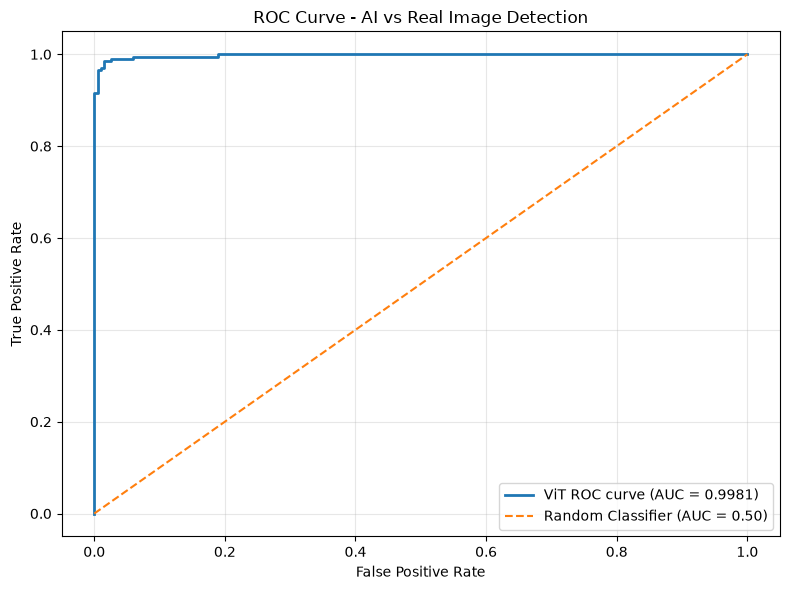

In [38]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize

# ==========================================
# Get predictions from test dataset
# ==========================================

predictions = trainer.predict(test_data)

# Model logits
logits = predictions.predictions

# True labels
y_true = predictions.label_ids

# Convert logits to probabilities
probs = np.exp(logits) / np.sum(np.exp(logits), axis=1, keepdims=True)

# Probability of FAKE class
# Your mapping is:
# 0 = REAL
# 1 = FAKE
y_score = probs[:, 1]

# ==========================================
# Calculate ROC curve
# ==========================================

fpr, tpr, thresholds = roc_curve(y_true, y_score)

# Calculate AUC
roc_auc = auc(fpr, tpr)

print("ROC-AUC:", roc_auc)

# ==========================================
# Plot ROC Curve
# ==========================================

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"ViT ROC curve (AUC = {roc_auc:.4f})"
)

# Random classifier reference line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Random Classifier (AUC = 0.50)"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - AI vs Real Image Detection")

plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()